# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

## 핵심 계산 풀이

학습용 손글씨풍 계산 정리임. 아래 실습과 같은 A,b를 사용함. R₁,R₂,R₃는 행 번호이며, 소거 후 z,y,x 순서로 역대입함.

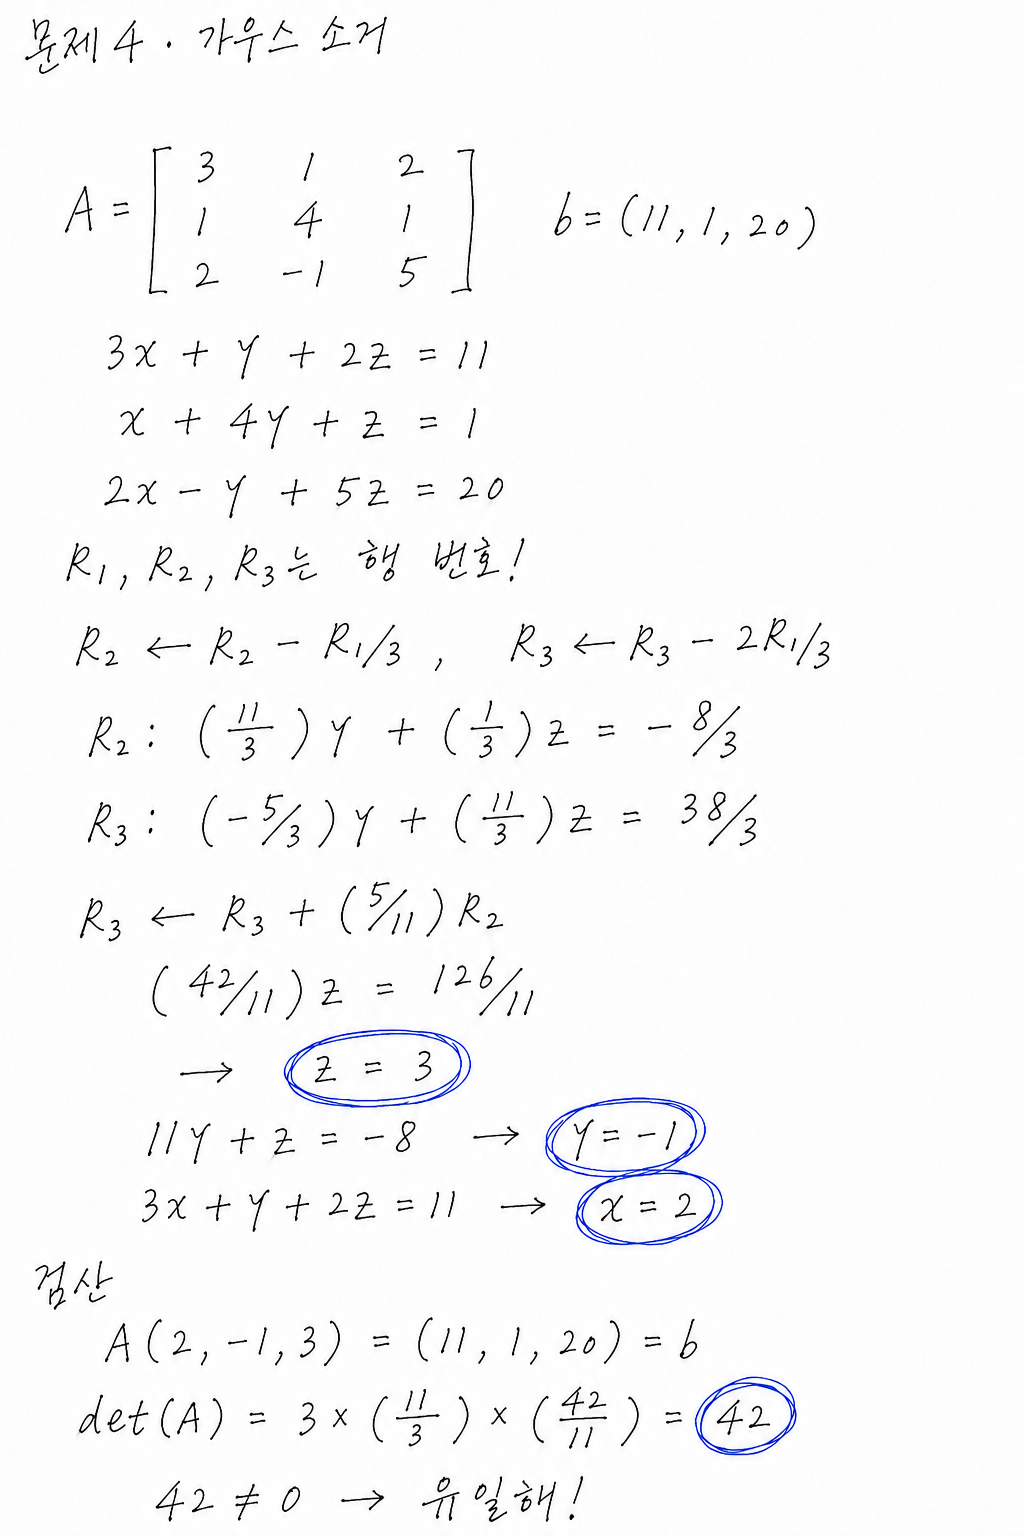

[계산 그림 PNG 원본](../images/handwritten_math/04_linear_system.png)


In [1]:
import sys
print("실행 Python:", sys.executable)
print("가상환경 사용:", sys.prefix != sys.base_prefix)


실행 Python: /home/chsjh/.venvs/physicalai-lv1-math/bin/python
가상환경 사용: True


In [2]:
from pathlib import Path
from matplotlib import font_manager

# 한글과 수학 기호를 함께 지원하는 글꼴을 등록한다.
# WSL: Windows 글꼴, 일반 Ubuntu: fonts-noto-cjk 패키지를 사용한다.
for font_path in (Path("/mnt/c/Windows/Fonts/NotoSansKR-VF.ttf"),
                  Path("C:/Windows/Fonts/NotoSansKR-VF.ttf"),
                  Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")):
    if font_path.is_file():
        font_manager.fontManager.addfont(str(font_path))
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next((name for name in ("Noto Sans KR", "Noto Sans CJK KR", "Noto Sans CJK JP")
                    if name in available_fonts), None)
if korean_font is None:
    raise RuntimeError("Noto 한글 글꼴이 필요함. Ubuntu: sudo apt install fonts-noto-cjk")
print("한글·수학 글꼴:", korean_font)


한글·수학 글꼴: Noto Sans KR


In [3]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


In [4]:
# 제공된 그림에서 한글과 음수 지수가 함께 읽히도록 설정한다.
plt.rcParams["font.family"] = korean_font


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [5]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError(f"정사각 행렬 A가 필요합니다. 받은 shape={A.shape}")
    if b.ndim != 1 or b.shape[0] != A.shape[0]:
        raise ValueError(f"b는 길이 {A.shape[0]}인 벡터여야 합니다. 받은 shape={b.shape}")

    n = A.shape[0]
    augmented = np.column_stack((A.copy(), b.copy()))
    scale = float(np.max(np.abs(A))) if A.size else 0.0
    tol = max(1, n) * np.finfo(float).eps * max(1.0, scale)
    # 비피벗 모드는 문제

In [6]:
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

초기 [A|b]:
 [[ 3.  1.  2. 11.]
 [ 1.  4.  1.  1.]
 [ 2. -1.  5. 20.]]
1단계 [A|b]:
 [[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]
2단계 [A|b]:
 [[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]
3단계 [A|b]:
 [[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]


In [7]:
residual_main = A @ x - b
x_reference = np.linalg.solve(A, b)
print("최종 해 x:", x)
print("정수해 여부:", np.allclose(x, np.round(x)))
print("A @ x:", A @ x, "/ b:", b)
print("잔차 노름 |Ax-b|:", np.linalg.norm(residual_main))
print("np.linalg.solve 검산:", x_reference)

최종 해 x: [ 2. -1.  3.]
정수해 여부: True
A @ x: [11.  1. 20.] / b: [11.  1. 20.]
잔차 노름 |Ax-b|: 3.580361673049448e-15
np.linalg.solve 검산: [ 2. -1.  3.]


In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: $b$가 $A$의 열공간에 포함되어 연립방정식이 모순 없이 해를 가집니다.
- 다를 때: $b$가 열공간 밖에 있어 소거 결과에 계수는 모두 0인데 우변만 0이 아닌 모순 행이 생깁니다.
- 같지만 n 보다 작을 때: 해는 존재하지만 피벗 없는 자유변수가 있어 무한히 많은 해가 생깁니다.

In [9]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],
                  [1.0, 1.0, 1.0]])
rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]
print("rank(A):", rA, "/ rank([A|b]):", rAb, "/ 미지수:", n_unknowns)
print("NumPy rank 검산:", np.linalg.matrix_rank(A), np.linalg.matrix_rank(Ab))
print("판정: 유일해" if rA == rAb == n_unknowns else "판정 조건 재확인 필요")

b_bad = np.array([1.0, 4.0, 2.0])
b_ok = np.array([1.0, 3.0, 2.0])
Ab_bad = np.column_stack([A_dep, b_bad])
Ab_ok = np.column_stack([A_dep, b_ok])
U_bad, _, _ = row_echelon(Ab_bad)
U_ok, _, _ = row_echelon(Ab_ok)
print("모순: rank(A), rank([A|b]) =", rank(A_dep), rank(Ab_bad), "/ 마지막 행:", U_bad[-1])
print("무모순 종속: rank(A), rank([A|b]) =", rank(A_dep), rank(Ab_ok), "/ 마지막 행:", U_ok[-1])

rank(A): 3 / rank([A|b]): 3 / 미지수: 3
NumPy rank 검산: 3 3
판정: 유일해
모순: rank(A), rank([A|b]) = 2 3 / 마지막 행: [ 0.        0.        0.       -0.333333]
무모순 종속: rank(A), rank([A|b]) = 2 2 / 마지막 행: [0. 0. 0. 0.]


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: $1/\det(A)$가 매우 커져 입력과 반올림 오차가 역행렬 성분에서 증폭될 수 있습니다.
- 소거 관점: 작은 피벗으로 나누면 큰 소거 계수가 생기고 큰 수끼리의 뺄셈에서 유효숫자가 손실됩니다.
- 스케일 실험에서 관찰한 것: 행렬 전체를 축소하면 det는 $s^n$만큼 작아져도 조건수와 해의 상대 정확도는 거의 바뀌지 않습니다.
- 실무 판정 기준과 그 의미: 스케일 의존적인 det 단독값보다 조건수 $\kappa(A)$로 입력 오차가 해에서 얼마나 증폭되는지를 판단합니다.

In [11]:
detA = det(A)
invA = inverse_gauss_jordan(A)
print("직접 det / NumPy 검산:", detA, "/", np.linalg.det(A))
print("직접 구한 역행렬:")
print(invA)
print("NumPy 역행렬 검산:")
print(np.linalg.inv(A))
print("A @ invA:")
print(A @ invA)
print("invA @ b:", invA @ b, "/ 가우스 소거 해:", x)

직접 det / NumPy 검산: 42.0 / 42.00000000000001
직접 구한 역행렬:
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
NumPy 역행렬 검산:
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
A @ invA:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
invA @ b: [ 2. -1.  3.] / 가우스 소거 해: [ 2. -1.  3.]


In [12]:
x_exact = x.copy()
print("스케일만 바꾼 경우")
print(f"{'scale':>10} {'det':>14} {'cond':>14} {'상대오차':>14}")
scale_rows = []
for scale in [1.0, 1e-1, 1e-2, 1e-3]:
    xs, _ = gauss_eliminate(scale * A, scale * b, pivoting=True)
    rel = np.linalg.norm(xs - x_exact) / np.linalg.norm(x_exact)
    cond = np.linalg.cond(scale * A)
    scale_rows.append((scale, det(scale * A), cond, rel))
    print(f"{scale:10.1e} {det(scale * A):14.6e} {cond:14.6e} {rel:14.6e}")

print("거의 특이해지는 경우")
print(f"{'eps':>10} {'det':>14} {'cond':>14} {'상대오차':>14}")
near_rows = []
exact2 = np.array([1.0, 1.0])
for eps in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]:
    A_near = np.array([[1.0, 2.0], [2.0, 4.0 + eps]])
    b_near = A_near @ exact2
    x_near = np.linalg.solve(A_near, b_near)
    rel = np.linalg.norm(x_near - exact2) / np.linalg.norm(exact2)
    near_rows.append((eps, np.linalg.det(A_near), np.linalg.cond(A_near), rel))
    print(f"{eps:10.1e} {np.linalg.det(A_near):14.6e} {np.linalg.cond(A_near):14.6e} {rel:14.6e}")

스케일만 바꾼 경우
     scale            det           cond           상대오차
   1.0e+00   4.200000e+01   4.214603e+00   0.000000e+00
   1.0e-01   4.200000e-02   4.214603e+00   2.517749e-16
   1.0e-02   4.200000e-05   4.214603e+00   4.672745e-16
   1.0e-03   4.200000e-08   4.214603e+00   1.483598e-16
거의 특이해지는 경우
       eps            det           cond           상대오차
   1.0e-02   1.000000e-02   2.508010e+03   0.000000e+00
   1.0e-04   1.000000e-04   2.500080e+05   0.000000e+00
   1.0e-06   1.000000e-06   2.500001e+07   0.000000e+00
   1.0e-08   1.000000e-08   2.500000e+09   0.000000e+00
   1.0e-10   1.000000e-10   2.499989e+11   0.000000e+00
   1.0e-12   1.000089e-12   2.497608e+13   0.000000e+00


In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- 작은 첫 피벗으로 나누면서 $1/\varepsilon$ 크기의 소거 계수가 생기고, 이어지는 큰 수의 상쇄에서 유효숫자를 잃습니다. 부분 피벗팅은 크기 1인 행을 먼저 써 이 증폭을 피합니다.

In [14]:
def solve_eps(eps):
    """eps 하나에 대해 참해, 두 소거해, 각각의 상대오차를 반환한다."""
    Ae = np.array([[eps, 1.0], [1.0, 1.0]])
    be = np.array([1.0, 2.0])
    exact = np.array([1.0 / (1.0 - eps), (1.0 - 2.0 * eps) / (1.0 - eps)])
    x_no, _ = gauss_eliminate(Ae, be, pivoting=False)
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True)
    denominator = np.linalg.norm(exact)
    rel_err_no = np.linalg.norm(x_no - exact) / denominator
    rel_err_pp = np.linalg.norm(x_pp - exact) / denominator
    return exact, x_no, x_pp, rel_err_no, rel_err_pp


EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)
exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
print("eps=1e-5 참해:", exact)
print("피벗팅 없음:", x_no, "/ 상대오차:", err_no)
print("부분 피벗팅:", x_pp, "/ 상대오차:", err_pp)

errs_no, errs_pp = [], []
print(f"{'eps':>12} {'피벗팅 없음':>16} {'부분 피벗팅':>16}")
for eps in eps_list:
    _, _, _, e_no, e_pp = solve_eps(eps)
    errs_no.append(max(e_no, 1e-18))
    errs_pp.append(max(e_pp, 1e-18))
    print(f"{eps:12.1e} {e_no:16.6e} {e_pp:16.6e}")

eps=1e-5 참해: [1.00001 0.99999]
피벗팅 없음: [1.00001 0.99999] / 상대오차: 2.6901964197197188e-12
부분 피벗팅: [1.00001 0.99999] / 상대오차: 0.0
         eps           피벗팅 없음           부분 피벗팅
     1.0e-02     3.297026e-15     1.570012e-16
     1.0e-03     1.601494e-14     0.000000e+00
     1.0e-04     1.989307e-13     1.570092e-16
     1.0e-05     2.690196e-12     0.000000e+00
     1.0e-06     3.983796e-12     1.570092e-16
     1.0e-07     3.563319e-10     0.000000e+00
     1.0e-08     3.518027e-09     1.570092e-16
     1.0e-09     2.070545e-08     0.000000e+00
     1.0e-10     5.843557e-08     0.000000e+00
     1.0e-11     5.849921e-08     0.000000e+00
     1.0e-12     1.564242e-05     0.000000e+00
     1.0e-13     2.198715e-04     1.570092e-16
     1.0e-14     5.651748e-04     0.000000e+00
     1.0e-15     5.651748e-04     1.570092e-16
     1.0e-16     8.629857e-01     1.570092e-16


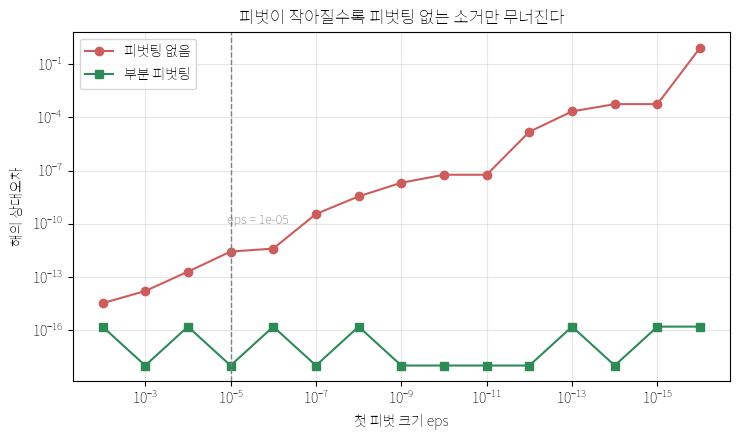

In [15]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [16]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: LU 분해 후 `solve`는 대략 $2n^3/3+O(n^2)$, 역행렬 계산 후 곱은 분해에 더해 모든 단위 우변을 풀어야 해 더 많은 $O(n^3)$ 연산이 듭니다.
- 정확도: `solve`는 중간 역행렬을 만들지 않아 반올림 오차가 덜 누적되고 일반적으로 잔차가 더 작습니다.
- 메모리: 명시적 역행렬은 추가 $n\times n$ 배열을 저장해야 하지만 `solve`는 이를 피할 수 있습니다.
- 우변이 여러 개일 때는: 한 번의 분해를 재사용해 여러 우변을 직접 풉니다. 역행렬을 먼저 만들 필요는 없습니다.
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: 알고리즘의 산출물 자체가 역행렬이어야 하거나 역행렬 원소를 직접 분석해야 할 때입니다.

In [17]:
from threadpoolctl import threadpool_info, threadpool_limits

N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10

def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다."""
    fn()
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out

# 병렬화 비용의 영향을 줄이려고 두 방법을 같은 단일 BLAS 스레드로 비교함.
with threadpool_limits(limits=1, user_api="blas"):
    print("측정 BLAS 설정:", [(p["internal_api"], p["num_threads"]) for p in threadpool_info() if p["user_api"] == "blas"])
    t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
    t_inv, x_inv = bench(lambda: np.linalg.inv(A_big) @ b_big)
    res_solve = np.linalg.norm(A_big @ x_solve - b_big)
    res_inv = np.linalg.norm(A_big @ x_inv - b_big)

inverse_memory_mib = A_big.nbytes / (1024 ** 2)
print(f"{'방법':<12} {'시간(ms)':>12} {'잔차':>14}")
print(f"{'solve':<12} {t_solve * 1e3:12.3f} {res_solve:14.6e}")
print(f"{'inv @ b':<12} {t_inv * 1e3:12.3f} {res_inv:14.6e}")
print("명시적 800x800 역행렬 저장 공간:", inverse_memory_mib, "MiB")

측정 BLAS 설정: [('openblas', 1)]
방법                 시간(ms)             잔차
solve               6.742   8.000724e-12
inv @ b            24.834   1.618627e-11
명시적 800x800 역행렬 저장 공간: 4.8828125 MiB


In [18]:
N_COND = 80
Q1, _ = np.linalg.qr(rng.standard_normal((N_COND, N_COND)))
Q2, _ = np.linalg.qr(rng.standard_normal((N_COND, N_COND)))
x_known = rng.standard_normal(N_COND)
condition_rows = []
print(f"{'목표 조건수':>14} {'실제 조건수':>14} {'solve 상대오차':>18} {'inv 상대오차':>18}")
for target_cond in [1e2, 1e6, 1e10]:
    singular_values = np.logspace(0.0, -np.log10(target_cond), N_COND)
    A_cond = (Q1 * singular_values) @ Q2.T
    b_cond = A_cond @ x_known
    xs = np.linalg.solve(A_cond, b_cond)
    xi = np.linalg.inv(A_cond) @ b_cond
    err_s = np.linalg.norm(xs - x_known) / np.linalg.norm(x_known)
    err_i = np.linalg.norm(xi - x_known) / np.linalg.norm(x_known)
    actual_cond = np.linalg.cond(A_cond)
    condition_rows.append((target_cond, actual_cond, err_s, err_i))
    print(f"{target_cond:14.1e} {actual_cond:14.3e} {err_s:18.6e} {err_i:18.6e}")

        목표 조건수         실제 조건수         solve 상대오차           inv 상대오차
       1.0e+02      1.000e+02       5.192233e-15       2.838120e-14
       1.0e+06      1.000e+06       1.529436e-11       1.107018e-10
       1.0e+10      1.000e+10       6.278015e-08       1.488878e-06


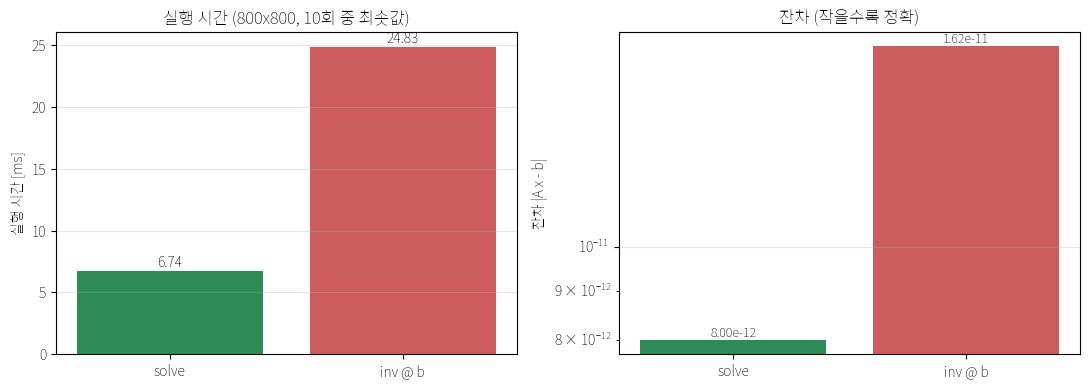

In [19]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [20]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [21]:
summary = f"""
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = {x}

2. rank A: {rA} / rank 첨가행렬: {rAb}   (미지수 3개)
   - 해의 존재·유일성 판정: 두 rank가 미지수 수 3과 같으므로 유일해
   - 두 rank가 같으면 b가 A의 열공간에 있어 해가 존재하고, 다르면 모순이라 해가 없으며, 같지만 n보다 작으면 자유변수가 있어 무한해이다.

3. 행렬식: {detA:.6f}
   역행렬:
   {invA}
   - det 이 0 에 가까울 때 위험한 이유: 작은 피벗으로 나누며 반올림 오차가 증폭될 수 있다.
   - 실제 판정 기준: det의 절댓값은 스케일에 민감하므로 상대 민감도를 나타내는 조건수를 함께 본다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): {err_no:.6e} / {err_pp:.6e}
   - eps 를 더 줄이면: 비피벗 해는 붕괴하지만 부분 피벗 해는 기계정밀도 수준을 유지한다.
   - 유효숫자가 날아가는 지점: 첫 행을 1/eps 배 해 두 번째 행에서 뺄 때 큰 수끼리 상쇄된다.

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : {t_solve * 1e3:.3f} ms / {t_inv * 1e3:.3f} ms
   - 잔차 : {res_solve:.6e} / {res_inv:.6e}
   - 조건수를 키웠을 때의 정확도 차이: 둘 다 악화되지만 명시적 역행렬 곱은 추가 반올림과 연산으로 대체로 더 불리하다.
   - 결론: Ax=b는 분해 후 직접 푸는 solve를 사용하고, 선형 연산자 자체가 꼭 필요할 때만 역행렬을 명시적으로 만든다.
"""
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: 두 rank가 미지수 수 3과 같으므로 유일해
   - 두 rank가 같으면 b가 A의 열공간에 있어 해가 존재하고, 다르면 모순이라 해가 없으며, 같지만 n보다 작으면 자유변수가 있어 무한해이다.

3. 행렬식: 42.000000
   역행렬:
   [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
   - det 이 0 에 가까울 때 위험한 이유: 작은 피벗으로 나누며 반올림 오차가 증폭될 수 있다.
   - 실제 판정 기준: det의 절댓값은 스케일에 민감하므로 상대 민감도를 나타내는 조건수를 함께 본다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 2.690196e-12 / 0.000000e+00
   - eps 를 더 줄이면: 비피벗 해는 붕괴하지만 부분 피벗 해는 기계정밀도 수준을 유지한다.
   - 유효숫자가 날아가는 지점: 첫 행을 1/eps 배 해 두 번째 행에서 뺄 때 큰 수끼리 상쇄된다.

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : 6.742 ms / 24.834 ms
   - 잔차 : 8.000724e-12 / 1.618627e-11
   - 조건수를 키웠을 때의 정확도 차이: 둘 다 악화되지만 명시적 역행렬 곱은 추가 반올림과 연산으로 대체로 더 불리하다.
   - 결론: Ax=b는 분해 후 직접 푸는 solve를 사용하고, 선형 연산자 자체가 꼭 필요할 때만 역행렬을 명시적으로 만든다.

